In [9]:
import pandas as pd

In [21]:
# 使用波士顿房价数据来进行演示

# 读取数据
house_data = pd.read_csv("./BostonHousing.csv")

print(len(house_data), house_data.shape) 

# feature = house_data.drop("medv", axis=1)  # 去除最后一列房价
feature = house_data
print(len(feature), feature.shape)

506 (506, 14)
506 (506, 14)


In [23]:

# 计算相关系数矩阵
correlation_matrix = feature.corr()


# 1. 与目标变量相关性
target_corr = correlation_matrix['MEDV'].drop('MEDV')  # 去掉自己
print("\n各特征与目标变量相关系数:\n", target_corr)


KeyError: 'MEDV'

In [30]:
# 假设已有数据集 df
df = pd.read_csv("./BostonHousing.csv")

# 这里用波士顿房价数据举例
# from sklearn.datasets import load_boston
# boston = load_boston()
# df = pd.DataFrame(boston.data, columns=boston.feature_names)
# df['MEDV'] = boston.target  # 添加房价列

# 计算相关系数矩阵
corr_matrix = df.corr()
print("相关系数矩阵:\n", corr_matrix)

# 1. 与目标变量相关性
target_corr = corr_matrix['medv'].drop('medv')  # 去掉自己 pandas对列字段的大小写敏感
print("\n各特征与目标变量相关系数:\n", target_corr)

# 选择与目标变量相关系数绝对值大于阈值的特征
threshold = 0.5
selected_features = target_corr[abs(target_corr) > threshold].index.tolist()
print("\n筛选出的特征:", selected_features)

# 2. 特征间相关性过滤（剔除高度相关特征）
# 设置高度相关阈值
high_corr = 0.8
upper = corr_matrix[selected_features].abs()
# 遍历上三角矩阵，删除高度相关特征
to_drop = []
for i in range(len(upper.columns)):
    for j in range(i):
        if upper.iloc[i, j] > high_corr:
            colname = upper.columns[i]
            if colname not in to_drop:
                to_drop.append(colname)
print("\n剔除高度相关特征:", to_drop)

# 最终保留特征
final_features = [f for f in selected_features if f not in to_drop]
print("\n最终保留特征:", final_features)

相关系数矩阵:
              crim        zn     indus      chas       nox        rm       age  \
crim     1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247  0.352734   
zn      -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991 -0.569537   
indus    0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676  0.644779   
chas    -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251  0.086518   
nox      0.420972 -0.516604  0.763651  0.091203  1.000000 -0.302188  0.731470   
rm      -0.219247  0.311991 -0.391676  0.091251 -0.302188  1.000000 -0.240265   
age      0.352734 -0.569537  0.644779  0.086518  0.731470 -0.240265  1.000000   
dis     -0.379670  0.664408 -0.708027 -0.099176 -0.769230  0.205246 -0.747881   
rad      0.625505 -0.311948  0.595129 -0.007368  0.611441 -0.209847  0.456022   
tax      0.582764 -0.314563  0.720760 -0.035587  0.668023 -0.292048  0.506456   
ptratio  0.289946 -0.391679  0.383248 -0.121515  0.188933 -0.355501  0.261515   
b       -0.385064  

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

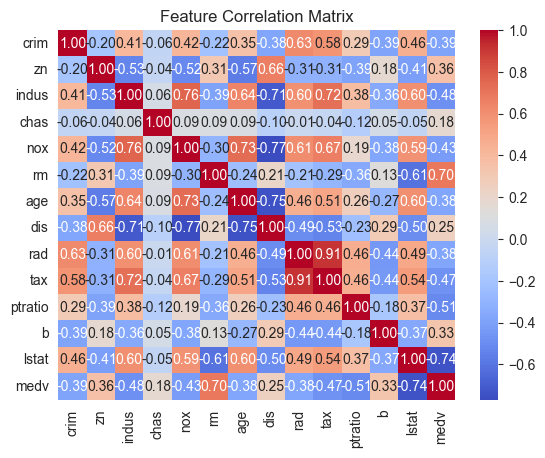

In [2]:
df = pd.read_csv('./BostonHousing.csv')
df_corr = df.corr()
 # 可视化热力图
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()